In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 1. Data Import and Formatting

We know beforehand the shape and column names and datatypes of the table we are importing because we built it.

Explicitely importing the data in the expected format is very good practice in this case: it avoids unexpected problems/bugs caused by how the data were automatically imported (which [built-in data class](https://docs.python.org/3/library/stdtypes.html) and its properties), and it is easy to maintain because we "control" the data input.


**What we want to plot**
1. x-axis : date of publication
2. y1-axis : number of papers **(a)** total retrieved **(b)** retrieved by publisher (on date XXXXX)
3. y2-axis : % of OA papers (as of date XXXXX) **(a)** of total retrieved **(b)** retrieved by publisher

**Columns to focus on**
1. "Publication Date"
2. "Publisher2"
3. "OA-noncomm"

In [2]:
data = pd.read_csv(
    "/var/storage/naji/Formatted_NCBI_data_20251129.csv",
    header=0,
    index_col=False,
    usecols=["PMID", "Publication Date", "Publisher", "OA-noncomm"],
    parse_dates=["Publication Date"],
)


In [3]:
print(data.dtypes)

PMID                         int64
Publisher                   object
OA-noncomm                    bool
Publication Date    datetime64[ns]
dtype: object


## 2. Select and format data for visualizing the Publisher/OA by publication date


# 3. Data cleaning 

This is unavoidably the first when dealing with such large public databases; there are always data inconsistences, down to how missing values are defined. Good thing we know what to expect with these curated data! 


If more data cleaning and formatting is needed add blocks below

In [4]:
#1. Unify Publisher names (modified from @naji code at github)

#add a new column instead of deleting, avoid different capitalization inconsistencies by lowercasing ALL here
data["Publisher2"]= data["Publisher"].str.lower()
# #keeping lowercase in the column with unified names to avoid the same problem
data.loc[data["Publisher2"].str.contains("wiley",case=False, na=False), "Publisher2"] = "wiley"
data.loc[data["Publisher2"].str.contains("Elsevier", case=False, na=False ), "Publisher2"] = "elsevier"
data.loc[data["Publisher2"].str.contains("MDPI", case=False, na=False), "Publisher2"] = "mdpi"
data.loc[data["Publisher2"].str.contains("Springer", case=False, na=False), "Publisher2"] = "springer"
data.loc[data["Publisher2"].str.contains("Proceedings of the National Academy of Sciences", case=False, na=False), "Publisher2"] = "pnas"
data.loc[data["Publisher2"].str.contains("Informa UK", case=False, na=False), "Publisher2"] = "informa uk"
data.loc[data["Publisher2"].str.contains("Hindawi", case=False, na=False), "Publisher2"] = "hindawi"
data.loc[data["Publisher2"].str.contains("Baishideng Publishing Group Co", case=False, na=False), "Publisher2"] = "baishideng" #making life easier for later in plot ledents
data.loc[data["Publisher2"].str.contains("Wolters Kluwer", case=False, na=False), "Publisher2"] = "wk"
data.loc[data["Publisher2"].str.contains("Public Library of Science", case=False, na=False), "Publisher2"] = "plos" #making life easier for later in plot legents
data.loc[data["Publisher2"].str.contains("American Chemical Society", case=False, na=False), "Publisher2"] = "acs" #making life easier for later in plot legents
data.loc[data["Publisher2"].str.contains("Oxford University Press", case=False, na=False), "Publisher2"] = "oup" #making life easier for later in plot legents
data.loc[data["Publisher2"].str.contains("American Society for Microbiology", case=False, na=False), "Publisher2"] = "asm" #making life easier for later in plot legents
data.loc[data["Publisher2"].str.contains("rockefeller", case=False, na=False), "Publisher2"] = "ru" #making life easier for later in plot legents


# 4. Plotting

## a. Determine groupping versions of the data with different date granularity 

This will assist with plotting different versions of the data later, based on date granularity. 
Also in this step we "get rid" of all the columns we don't focus in.

**NOTE**   The variables selected and used in the functions bellow are hard-coded and specific to what we want this plot to show. I still chose to allow flexibility to the functions so I can test out eg different time granularity (eg months, years etc), or publisher subset.  

### Function definitions

In [5]:
#Main functions (they do the "heavy lifting")
def TempGrouper(df, G="M"):
    
    ''' 
    Goupping function for the 
    results table where only variable 
    is the level of granularity (calendar).
    Called "Temp" because this grouper is 
    specific to the figure (and its axes).
    
    df: a pandas dataframe resulting from the retrieval pipeline,
    containing the columns "Publication Date",
    "OA-noncomm", "Publisher2", and "PMID" (these 
    are the specific data/columns we need to 
    use for this plot).
    
    Possible values for G are: 
    "D" groups by day NOT recommended as many dates miss day
    "W" groups by week NOT recommended as many dates miss day
    "M" groups by month (*default)
    "Q" groups by quarter
    "Y" groups by year'''
    
    grouped = pd.DataFrame(df.groupby([df["Publication Date"].dt.to_period(G)
              ,df["OA-noncomm"]
              ,df["Publisher2"]
             ])["PMID"].count()).reset_index()
    grouped2 = grouped.sort_values( by="Publication Date", ascending=True, inplace=False, ignore_index=True)
    return grouped2

def BlockFormater(df):
    # Version 1: sum PMIDs per (date, OA status)
    temp1 = (
        df.groupby([df["Publication Date"], df["OA-noncomm"]])["PMID"]
        .sum()
        .reset_index()
        .sort_values(by=["Publication Date", "OA-noncomm"])
    )

    # Fill missing True/False rows per date with 0
    dates = list(set(temp1["Publication Date"]))
    ref = pd.DataFrame({
        "Publication Date": dates + dates,
        "OA-noncomm": [True] * len(dates) + [False] * len(dates),
    }).sort_values(by=["Publication Date", "OA-noncomm"]).reset_index(drop=True)

    full = (
        pd.merge(ref, temp1, on=["Publication Date", "OA-noncomm"], how="outer")
        .sort_values(by="Publication Date")
        .fillna(value={"PMID": 0})
    )

    #temp3 = full.groupby([full["Publication Date"]], as_index=True).apply(lambda x: x / x.sum()).reset_index() ####### is buggy x / x.sum() divides every column (including non-numeric ones) by their column-wise sums, not just PMID. This means temp3["PMID"] represents the fraction of each row's PMID count relative to the total for that date — but the division is column-wise, not row-wise.#############

    # #Produce the final table: (1) per "groupping" (from "temp3" before) and (2) cummulative (here)
    # # number of PMIDs and fraction of OA .
    # temp2 = temp1.groupby([temp1["Publication Date"]], as_index=True).sum(
    #     ).reset_index().drop(["OA-noncomm"], axis=1)    
    # temp2["OA fraction"] = temp3[temp3['OA-noncomm']==1]['PMID'].values
    # temp2["PMID_cumsum"] = temp2["PMID"].cumsum()
    # temp2["OA fraction_cumsum"] = temp2["PMID"]*temp2["OA fraction"].cumsum()/temp2["PMID_cumsum"] This multiplies the current period's PMID count by the cumulative sum of OA fractions — which has no correct statistical meaning. The proper cumulative OA fraction is a weighted cumulative average
    # instead:
    # Compute OA fraction per date correctly
    oa_counts = full[full["OA-noncomm"] == True].set_index("Publication Date")["PMID"]
    total_counts = full.groupby("Publication Date")["PMID"].sum()
    oa_fraction_per_date = (oa_counts / total_counts).fillna(0).rename("OA fraction")

    # Build final table
    temp2 = (
        temp1.groupby(temp1["Publication Date"])
        .sum()
        .reset_index()
        .drop(["OA-noncomm"], axis=1)
    )
    temp2 = temp2.join(oa_fraction_per_date, on="Publication Date")
    temp2["PMID_cumsum"] = temp2["PMID"].cumsum()

    # corrected cumulative OA fraction: weighted cumulative average
    temp2["OA fraction_cumsum"] = (
        (temp2["PMID"] * temp2["OA fraction"]).cumsum() / temp2["PMID_cumsum"]
    )

    return temp2


def DataFormater(df, publisher):
    '''The variable 'publisher' has to be one of: 
    (a) True (all publishers in df), 
    (b) False (ignore publisher info), or 
    (c) a list (preselected publishers, eg top10)'''
    if not publisher: #publisher is False: no publisher distinction
        return BlockFormater(df)
    elif type(publisher)==bool and publisher: #publisher is True: include all publishers
        publisher = set(df["Publisher2"].values)
        d = {}
        for p in publisher:
            d[p] = BlockFormater(df[df['Publisher2']==p])
        return pd.concat(d, keys=d.keys()).reset_index().drop(labels="level_1",axis=1).rename(mapper={"level_0":"Publisher"}, axis=1)
    elif type(publisher)==list : #list of publishers to use is given (could be a list of one)
        d = {}
        for p in publisher:
            d[p] = BlockFormater(df[df['Publisher2']==p])
        return pd.concat(d, keys=d.keys()).reset_index().drop(labels="level_1",axis=1).rename(mapper={"level_0":"Publisher"}, axis=1)
    else: #catch-all error
        print("Error: The variable 'publisher' has to be one of: True, False, or a list. please enter your data correctly")    

### all in all 

| Function      | What it does                                                                                                           |
| ------------- | -------------------------------------------------------------------------------------------------                      |
| TempGrouper   | `Groupby` function acting on time period, OA status, and publisher, then counts PMIDs. acts on row data                |
| BlockFormater | Builds per-period totals, fills missing OA/non-OA rows, computes OA share and cumulative metrics. acts on `TempGrouper`|
| DataFormater  | Applies BlockFormater either once overall or separately by publisher. acts on `BlockFormater`                          |

In [6]:
#Auxiliary functions 

def topN(df, n=10):
    '''from @naji'''
    return df[["Publisher2", "PMID"]].groupby("Publisher2").count().sort_values(by="PMID",ascending=False)[0:n].index.to_list()

### Data prep 

Showing here for Monthly granularity/periodicity (our minimum granularity, see above_) and for the top10 publishers (all time). 

**@Naji** More plots to be added:
1. No publisher distinction, ie *publisher=False*
2. Top20 publishers (catches major publishers from early 19th century )

Repeat all for quarterly and yearly periodicity.

In [7]:
# group by month
ByMonth10pub = DataFormater(TempGrouper(data),publisher = topN(data, n=10))

# 3. Plotting

This is why we did all the data prep!

## a. Top10 publishers by month

In [8]:
# Turn date column (a time period pertiod dtype) into a datetime (each month represented as its first day) to enable timedate plotting

ByMonth10pub['datetime'] = ByMonth10pub['Publication Date'].dt.to_timestamp(how='start')

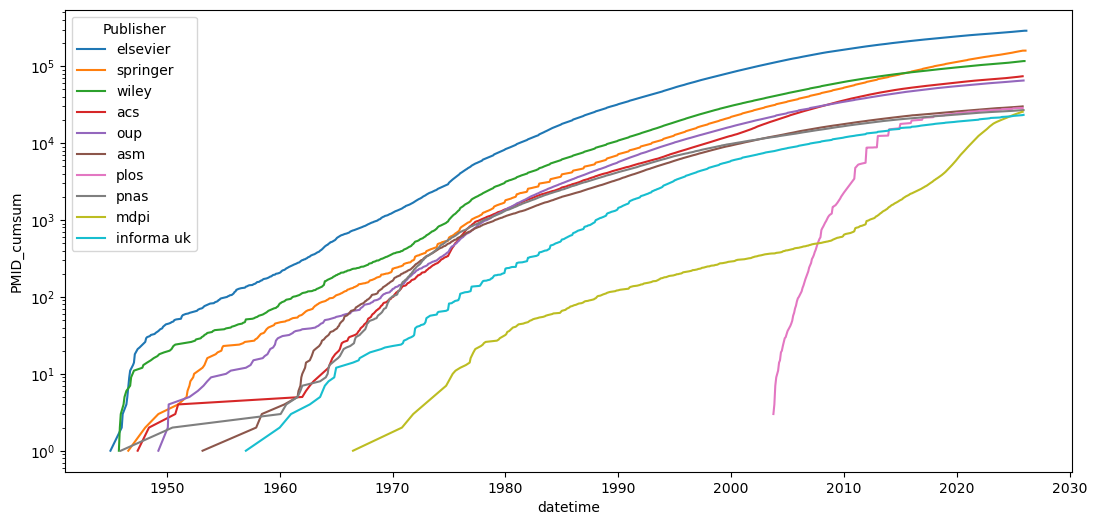

In [9]:
plt.figure(figsize=(13, 6)) # Adjust figure size
ax=sns.lineplot(data=ByMonth10pub, x='datetime', y="PMID_cumsum", hue="Publisher")
ax.set_yscale('log')

#Add second axis
#Add proper labels
plt.show()

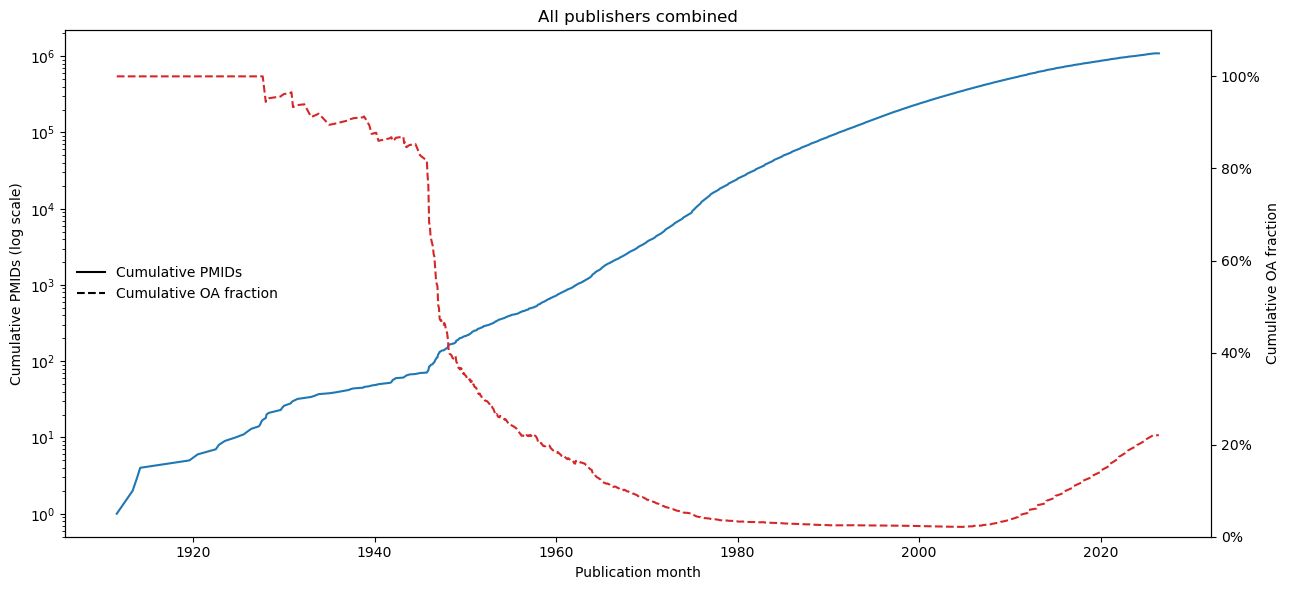

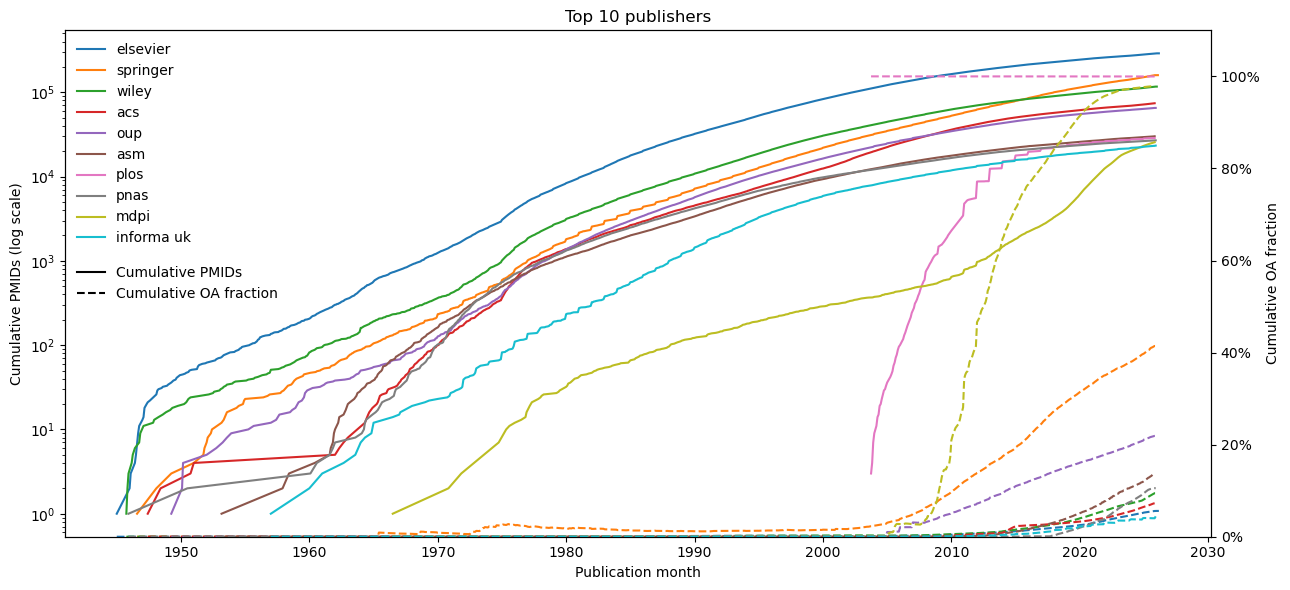

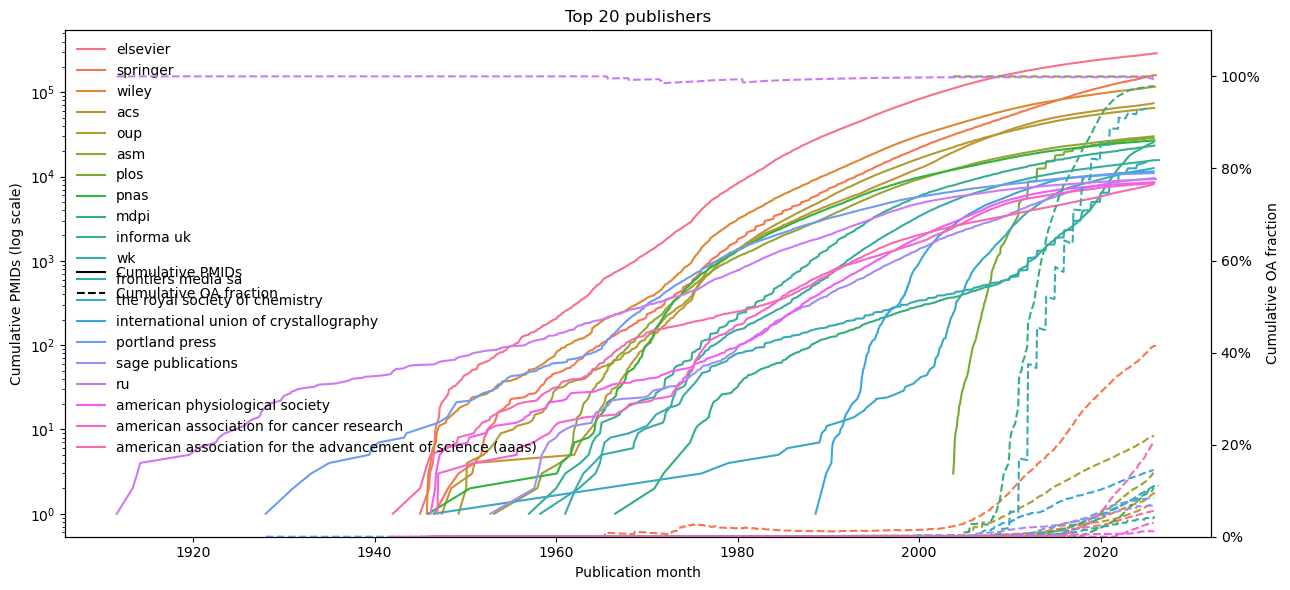

In [16]:
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

def make_pub_plot(plot_df, title, with_publishers=True):
    plot_df = plot_df.copy()
    plot_df["datetime"] = plot_df["Publication Date"].dt.to_timestamp(how="start")

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()

    if with_publishers:
        sns.lineplot(
            data=plot_df,
            x="datetime",
            y="PMID_cumsum",
            hue="Publisher",
            ax=ax1
        )

        sns.lineplot(
            data=plot_df,
            x="datetime",
            y="OA fraction_cumsum",
            hue="Publisher",
            ax=ax2,
            legend=False,
            linestyle="--"
        )
    else:
        sns.lineplot(
            data=plot_df,
            x="datetime",
            y="PMID_cumsum",
            ax=ax1,
            color="tab:blue"
        )

        sns.lineplot(
            data=plot_df,
            x="datetime",
            y="OA fraction_cumsum",
            ax=ax2,
            color="tab:red",
            linestyle="--"
        )

    ax1.set_yscale("log")
    ax1.set_xlabel("Publication month")
    ax1.set_ylabel("Cumulative PMIDs (log scale)")
    ax2.set_ylabel("Cumulative OA fraction")
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylim(0, 1.1)
    ax1.set_title(title)


 

    # 1) keep the publisher legend that seaborn created on ax1
    handles1, labels1 = ax1.get_legend_handles_labels()

    # 2) create custom handles for line types
    solid_handle = Line2D([0], [0], color="black", linestyle="-")
    dashed_handle = Line2D([0], [0], color="black", linestyle="--")

    # legend for line types, attach to ax2 (so it doesn't replace publisher legend)
    leg2 = ax2.legend(
        handles=[solid_handle, dashed_handle],
        labels=["Cumulative PMIDs", "Cumulative OA fraction"],
        loc="center left",
        frameon=False,
        title=None,
    )

    # (optional) re‑set the publisher legend explicitly on ax1 if needed
    ax1.legend(handles1, labels1, loc="upper left", frameon=False)


    plt.tight_layout()
    plt.show()

# ---------------------------
# Build plotting tables
# ---------------------------

grouped_month = TempGrouper(data, G="M")

ByMonth_all = DataFormater(grouped_month, publisher=False)
ByMonth_10pub = DataFormater(grouped_month, publisher=topN(data, n=10))
ByMonth_20pub = DataFormater(grouped_month, publisher=topN(data, n=20))

# ---------------------------
# Plots
# ---------------------------

make_pub_plot(ByMonth_all, "All publishers combined", with_publishers=False)
make_pub_plot(ByMonth_10pub, "Top 10 publishers", with_publishers=True)
make_pub_plot(ByMonth_20pub, "Top 20 publishers", with_publishers=True)


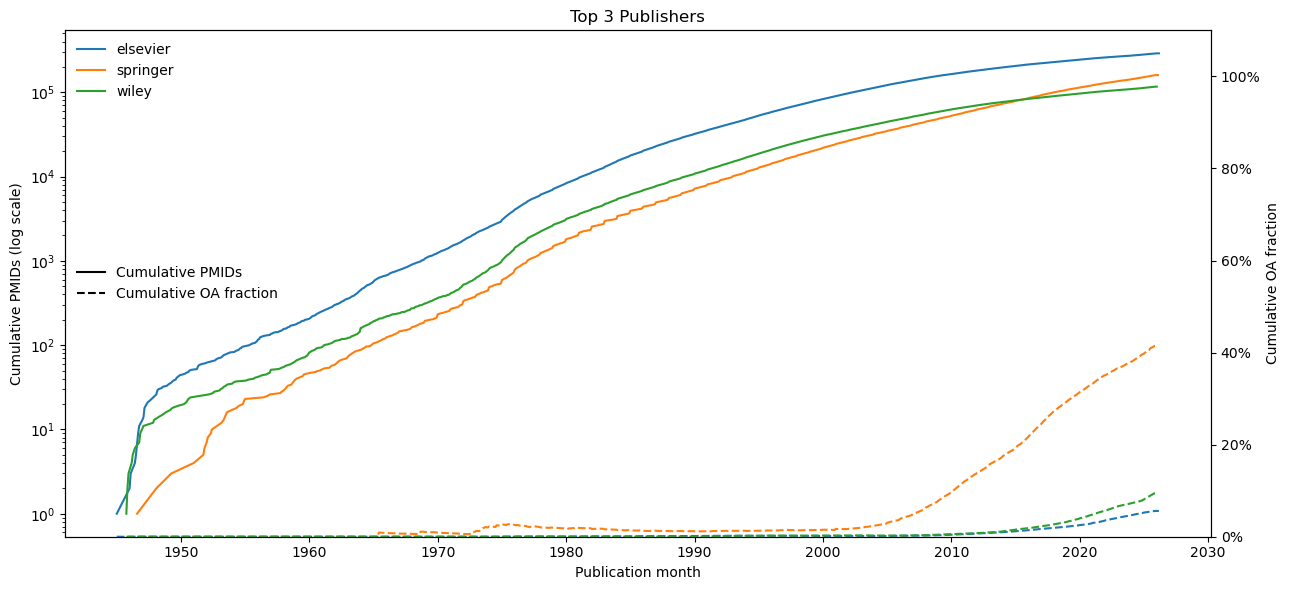

In [17]:
# get top 3
top3 = topN(data, n=3)


ByMonth_1_3pub = DataFormater(grouped_month, publisher=top3)
make_pub_plot(ByMonth_1_3pub, "Top 3 Publishers", with_publishers=True)



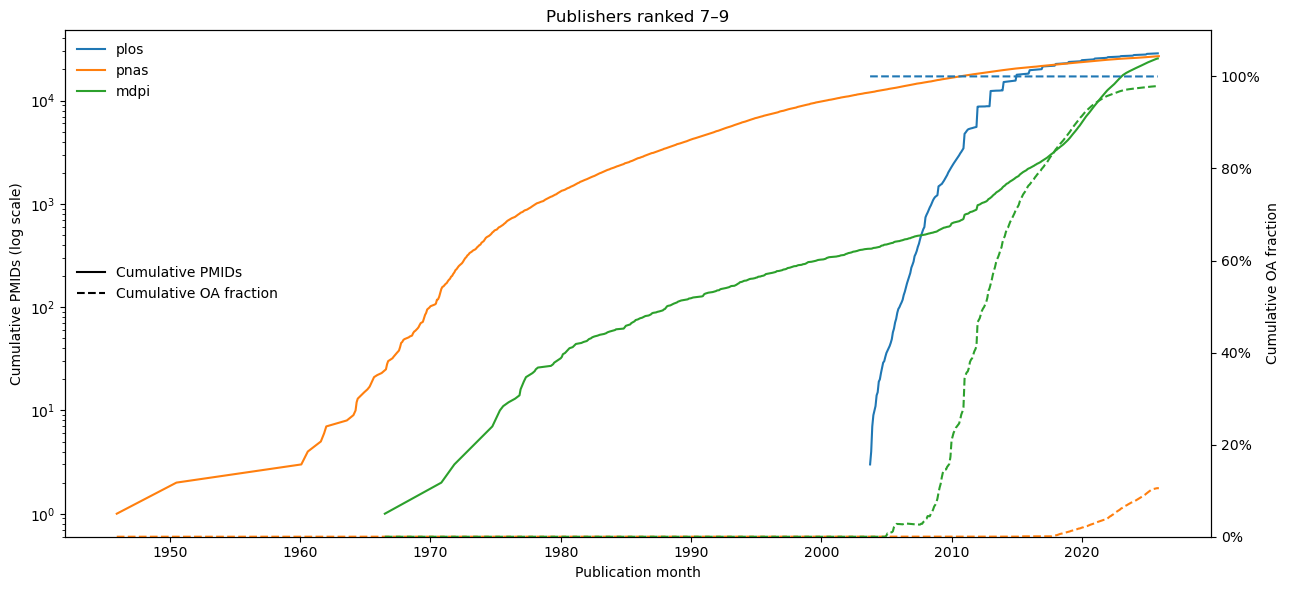

In [20]:
# build grouped data once
grouped_month = TempGrouper(data, G="M")

# 1) full top-10, to define the color map and datetime
ByMonth_10pub = DataFormater(grouped_month, publisher=topN(data, n=10))
ByMonth_10pub = ByMonth_10pub.copy()
ByMonth_10pub["datetime"] = ByMonth_10pub["Publication Date"].dt.to_timestamp(how="start")

pub_order_10 = ByMonth_10pub["Publisher"].unique()
palette_10 = sns.color_palette("tab10", n_colors=len(pub_order_10))
color_map_10 = dict(zip(pub_order_10, palette_10))

# 2) publishers ranked 7-9
top9 = topN(data, n=9)
pub_7_to_9 = top9[6:9]


ByMonth_7_9pub = DataFormater(grouped_month, publisher=pub_7_to_9)
ByMonth_7_9pub = ByMonth_7_9pub.copy()
ByMonth_7_9pub["datetime"] = ByMonth_7_9pub["Publication Date"].dt.to_timestamp(how="start")





make_pub_plot(ByMonth_7_9pub, "Publishers ranked 7–9", with_publishers=True)


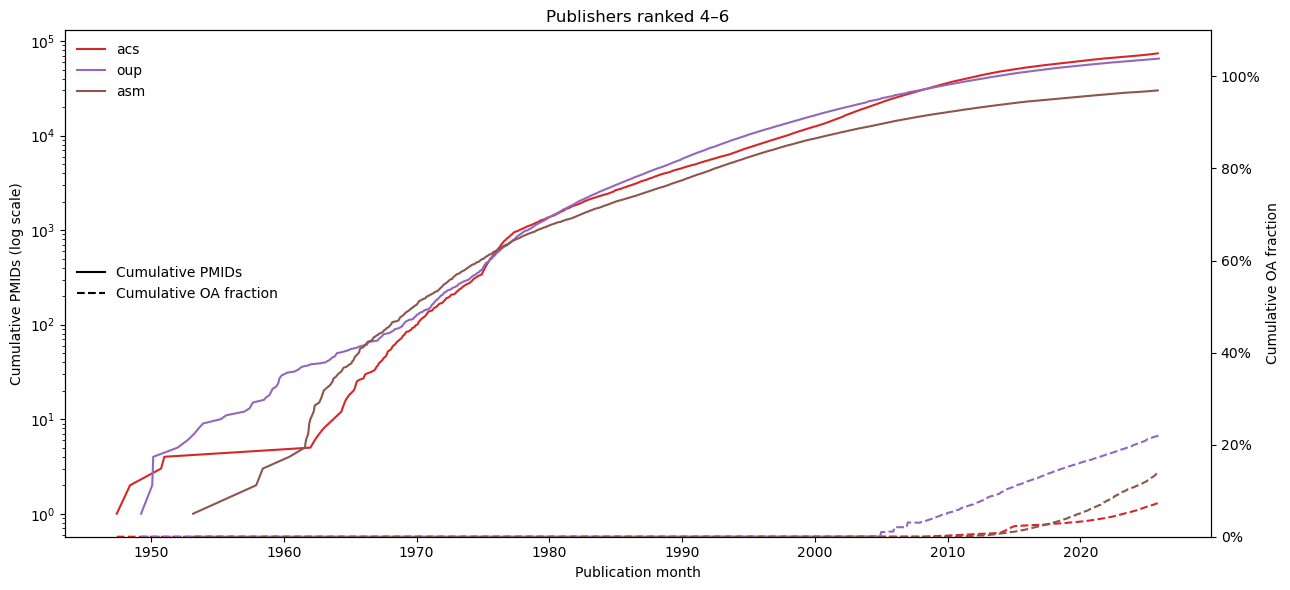

In [19]:
# build grouped data once
grouped_month = TempGrouper(data, G="M")

# 1) full top-10, to define the color map and datetime
ByMonth_10pub = DataFormater(grouped_month, publisher=topN(data, n=10))
ByMonth_10pub = ByMonth_10pub.copy()
ByMonth_10pub["datetime"] = ByMonth_10pub["Publication Date"].dt.to_timestamp(how="start")

pub_order_10 = ByMonth_10pub["Publisher"].unique()
palette_10 = sns.color_palette("tab10", n_colors=len(pub_order_10))
color_map_10 = dict(zip(pub_order_10, palette_10))

# 2) publishers ranked 4–6
top6 = topN(data, n=6)
pub_4_to_6 = top6[3:6]

ByMonth_4_6pub = DataFormater(grouped_month, publisher=pub_4_to_6)
ByMonth_4_6pub = ByMonth_4_6pub.copy()
ByMonth_4_6pub["datetime"] = ByMonth_4_6pub["Publication Date"].dt.to_timestamp(how="start")

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# PMIDs (solid)
sns.lineplot(
    data=ByMonth_4_6pub,
    x="datetime",
    y="PMID_cumsum",
    hue="Publisher",
    palette=color_map_10,
    ax=ax1,
)

# OA fraction (dashed, same colors)
sns.lineplot(
    data=ByMonth_4_6pub,
    x="datetime",
    y="OA fraction_cumsum",
    hue="Publisher",
    palette=color_map_10,
    ax=ax2,
    legend=False,
    linestyle="--",
)

ax1.set_yscale("log")
ax1.set_xlabel("Publication month")
ax1.set_ylabel("Cumulative PMIDs (log scale)")
ax2.set_ylabel("Cumulative OA fraction")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylim(0, 1.1)
ax1.set_title("Publishers ranked 4–6")

# ... plotting code ...

# 1) keep the publisher legend that seaborn created on ax1
handles1, labels1 = ax1.get_legend_handles_labels()

# 2) create custom handles for line types
solid_handle = Line2D([0], [0], color="black", linestyle="-")
dashed_handle = Line2D([0], [0], color="black", linestyle="--")

# legend for line types, attach to ax2 (so it doesn't replace publisher legend)
leg2 = ax2.legend(
    handles=[solid_handle, dashed_handle],
    labels=["Cumulative PMIDs", "Cumulative OA fraction"],
    loc="center left",
    frameon=False,
    title=None,
)

# (optional) re‑set the publisher legend explicitly on ax1 if needed
ax1.legend(handles1, labels1, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()


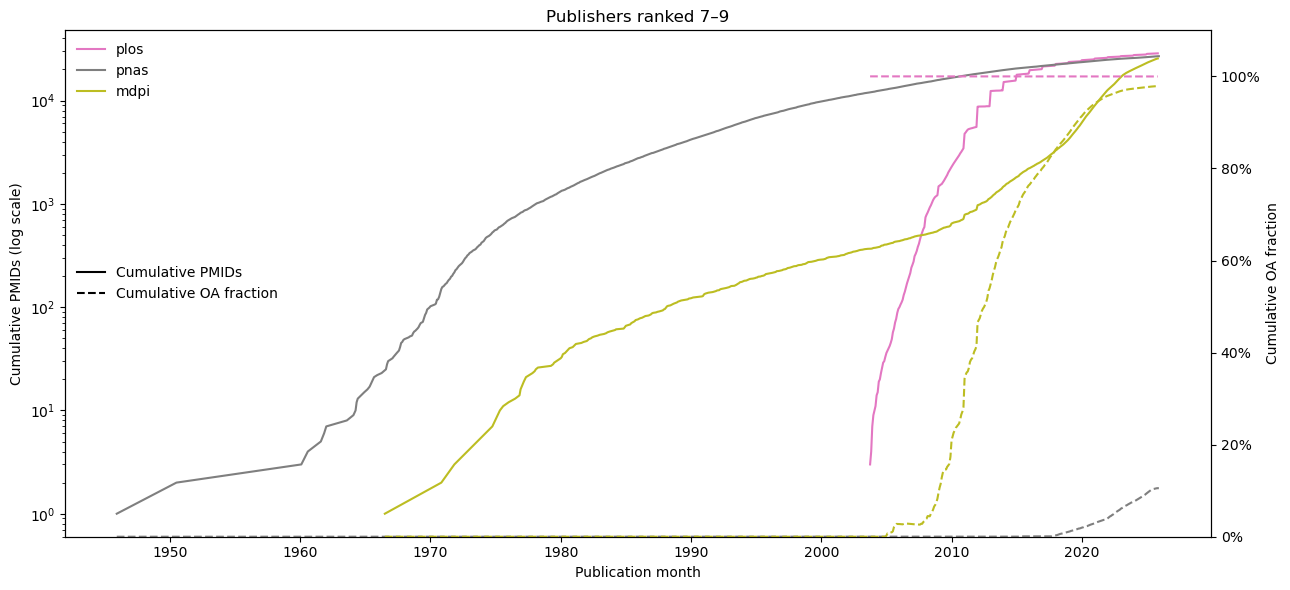

In [21]:
# build grouped data once
grouped_month = TempGrouper(data, G="M")

# 1) full top-10, to define the color map and datetime
ByMonth_10pub = DataFormater(grouped_month, publisher=topN(data, n=10))
ByMonth_10pub = ByMonth_10pub.copy()
ByMonth_10pub["datetime"] = ByMonth_10pub["Publication Date"].dt.to_timestamp(how="start")

pub_order_10 = ByMonth_10pub["Publisher"].unique()
palette_10 = sns.color_palette("tab10", n_colors=len(pub_order_10))
color_map_10 = dict(zip(pub_order_10, palette_10))

# 2) publishers ranked 4–6
# 2) publishers ranked 7-9
top9 = topN(data, n=9)
pub_7_to_9 = top9[6:9]


ByMonth_7_9pub = DataFormater(grouped_month, publisher=pub_7_to_9)
ByMonth_7_9pub = ByMonth_7_9pub.copy()
ByMonth_7_9pub["datetime"] = ByMonth_7_9pub["Publication Date"].dt.to_timestamp(how="start")

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# PMIDs (solid)
sns.lineplot(
    data=ByMonth_7_9pub,
    x="datetime",
    y="PMID_cumsum",
    hue="Publisher",
    palette=color_map_10,
    ax=ax1,
)

# OA fraction (dashed, same colors)
sns.lineplot(
    data=ByMonth_7_9pub,
    x="datetime",
    y="OA fraction_cumsum",
    hue="Publisher",
    palette=color_map_10,
    ax=ax2,
    legend=False,
    linestyle="--",
)

ax1.set_yscale("log")
ax1.set_xlabel("Publication month")
ax1.set_ylabel("Cumulative PMIDs (log scale)")
ax2.set_ylabel("Cumulative OA fraction")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylim(0, 1.1)
ax1.set_title("Publishers ranked 7–9")

# ... plotting code ...

# 1) keep the publisher legend that seaborn created on ax1
handles1, labels1 = ax1.get_legend_handles_labels()

# 2) create custom handles for line types
solid_handle = Line2D([0], [0], color="black", linestyle="-")
dashed_handle = Line2D([0], [0], color="black", linestyle="--")

# legend for line types, attach to ax2 (so it doesn't replace publisher legend)
leg2 = ax2.legend(
    handles=[solid_handle, dashed_handle],
    labels=["Cumulative PMIDs", "Cumulative OA fraction"],
    loc="center left",
    frameon=False,
    title=None,
)

# (optional) re‑set the publisher legend explicitly on ax1 if needed
ax1.legend(handles1, labels1, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()
